In [ ]:
metric = "kappa"
path = "/Users/Sandro/OneDrive/Documents/Uni/TESI/GIN/performance/TESTS_8concept"

future = "" if "future" not in path else "_future"

datasets = [f"sine_rw10_mode5{future}", f"weather{future}"]
print(datasets)
if "future" in path:
    datasets = [d for d in datasets if "sine" not in d]

confs_dict = {
    "weather": range(1,51),
    "sine_rw10_mode5": range(1,31),
}
start_batches = 50

['sine_rw10_mode5', 'weather']


In [20]:
if "future" not in datasets[0]:
    sml = "ARF_TA_anytime"
else:
    sml = "ARF_TA_feat_anytime"
    

In [5]:
import os
import pickle
import pandas as pd
import numpy as np
from evaluation.default_parameters import *

## Start End

In [6]:
os.chdir(os.path.dirname(os.getcwd()))
os.chdir(os.path.dirname(os.getcwd()))



In [5]:
df = pd.DataFrame()
for dataset in datasets:
    seq_len = set_seq_len(dataset)
    batch_size = set_batch_size(dataset)
    for conf in confs_dict[dataset]:
        print(dataset, conf, end="\r")
        with open(os.path.join(path, "exec", f"{dataset}_{conf}conf", f"performance_{batch_size}_{seq_len}.pkl"), "rb") as f:
            perf = pickle.load(f)
        model1 = list(perf.keys())[0]
        drifts = perf[model1]["drifts"][0] + [0]
        start_perf = {}
        end_perf = {}
        for model in perf:
            start_perf[model] = []
            end_perf[model] = []
            for i in range(len(drifts)-1):
                start = drifts[i] + start_batches*batch_size
                end = drifts[i+1]-1
                start_perf[model].append(perf[model]["task"][metric][0][start])
                end_perf[model].append(perf[model]["task"][metric][0][end])
            start_perf[model] = np.mean(start_perf[model])
            end_perf[model] = np.mean(end_perf[model])
        row = {
            "dataset": dataset.split("/")[-1],
            "conf": conf
        }
        for model in start_perf:
            row[f"start_{model.replace('_anytime', '')}"] =  start_perf[model]
        for model in end_perf:
            row[f"end_{model.replace('_anytime', '')}"] = end_perf[model]
        df = pd.concat([df, pd.DataFrame.from_dict({k: [row[k]] for k in row})])
    print()
df.round(2).to_excel(os.path.join(path, f"prequential_{metric}.xlsx"), index=False)
df.to_csv(os.path.join(path, f"prequential_{metric}.csv"), index=False)

df_original = df.copy()

air_quality 50
energy 50
sine_rw10_mode5 50
weather 50


In [6]:
df_mean = df_original.groupby("dataset").mean().round(2).reset_index().drop(columns="conf")
df_mean.to_excel(os.path.join(path, f"prequential_avg_{metric}.xlsx"), index=False)
df_mean

,dataset,start_ARF,start_ARF_TA_feat,start_ARF_TA,start_cLSTM,start_cPNN,start_DyncPNN,end_ARF,end_ARF_TA_feat,end_ARF_TA,end_cLSTM,end_cPNN,end_DyncPNN
0,air_quality,0.07,0.12,0.21,0.33,0.35,0.37,0.08,0.17,0.26,0.37,0.37,0.39
1,energy,0.25,0.15,0.21,0.65,0.66,0.69,0.29,0.21,0.28,0.74,0.71,0.76
2,sine_rw10_mode5,0.24,0.67,0.73,0.73,0.67,0.76,0.33,0.77,0.73,0.84,0.77,0.86
3,weather,0.26,0.30,0.42,0.53,0.50,0.60,0.29,0.34,0.44,0.64,0.53,0.66


In [7]:
df = df_original.copy().round(2)

In [8]:
from itertools import combinations

def only_best(x, s, model):
    if x[f"{s}_{model}"] != max(x):
        return 0
    others = [c for c in list(x.index) if c!=f"{s}_{model}"]
    for o in others:
        if x[o]==max(x):
            return 0
    return 1

dfs = {}
models = ["cPNN", "cLSTM", "DyncPNN"]
for s in ["start", "end"]:
    for model in models:
        df[f"{s}_{model}_best"] = df[[f"{s}_{m}" for m in models]].apply(
            lambda x: int(x[f"{s}_{model}"] == max(x)),axis=1
        )
        df[f"{s}_{model}_only_best"] = df[[f"{s}_{m}" for m in models]].apply(
            lambda x: only_best(x, s, model), axis=1
        )
    for m1, m2 in combinations(models, 2):
        df[f"{s}_{m1}_{m2}_bests"] = df[[f"{s}_{m}" for m in models]].apply(
            lambda x: int(x[f"{s}_{m1}"]==x[f"{s}_{m2}"] and  x[f"{s}_{m1}"]==max(x)),
            axis=1
        )
    df[f"{s}_all_bests"] = df[[f"{s}_{m}" for m in models]].apply(lambda x: int(len(set(x))==1), axis=1)

In [9]:
df = df[
    [c for c in df.columns if "start" not in c and "end" not in c] +
    [f"start_{model}_{b}best" for model in models for b in ["only_", ""]] +
    sorted([c for c in df.columns if "start" in c and "bests" in c]) +
    [f"end_{model}_{b}best" for model in models for b in ["only_", ""]] +
    sorted([c for c in df.columns if "end" in c and "bests" in c])
]

In [10]:
def build_stats(s):
    stats = df.groupby("dataset").agg({  
        c: "sum"
        for c in [col for col in df.columns if "best" in col and s in col]
    }).reset_index()
    for model in models:
        stats[f"{s}_{model}_best_barchart"] = stats[f"{s}_{model}_best"] - stats[f"{s}_{model}_only_best"]
    stats.to_excel(os.path.join(path, f"prequential_{metric}_stats_{s}.xlsx"), index=False)
    return stats

In [11]:
stats_start = build_stats("start")
stats_end = build_stats("end")

In [12]:
stats_start

,dataset,start_cPNN_only_best,start_cPNN_best,start_cLSTM_only_best,start_cLSTM_best,start_DyncPNN_only_best,start_DyncPNN_best,start_all_bests,start_cLSTM_DyncPNN_bests,start_cPNN_DyncPNN_bests,start_cPNN_cLSTM_bests,start_cPNN_best_barchart,start_cLSTM_best_barchart,start_DyncPNN_best_barchart
0,air_quality,6,14,1,3,35,43,2,2,8,2,8,2,8
1,energy,2,4,4,7,39,44,0,3,2,0,2,3,5
2,sine_rw10_mode5,0,1,0,6,43,50,0,6,1,0,1,6,7
3,weather,0,0,1,5,45,49,0,4,0,0,0,4,4


In [13]:
colors = {
    "air_quality": ((0.2, 0.4, 0.6), (0.7, 0.8, 0.9)),  # Blu
    "weather": ((0.6, 0.2, 0.4), (0.9, 0.7, 0.8)),  # Rosa
    "energy": ((0.4, 0.6, 0.2), (0.8, 0.9, 0.7)),   # Verde
    "sine_rw10_mode5": ((0.5, 0.2, 0.8), (0.8, 0.7, 0.9))  # Viola
}

keys = list(colors.keys())
for d in keys:
    colors[f"{d}_future"] = colors[d]

In [14]:
def build_bar_chart(ax, stats, s, df, models, bar_width=0.1):
    x_values = np.arange(len(models))
    datasets = list(stats["dataset"].unique())
    dati = np.array([
        [
            [
                stats[stats["dataset"]==dataset][f"{s}_{model}_only_best"].iloc[0],
                stats[stats["dataset"]==dataset][f"{s}_{model}_best_barchart"].iloc[0]
            ] for dataset in datasets
        ] for model in models
    ])

    for d in range(0,len(datasets)):
        barre_unstacked = ax.bar(x_values + bar_width * d, dati[:, d, 0], bar_width, color=colors[datasets[d]][0])
        barre_stacked = ax.bar(x_values + bar_width * d, dati[:, d, 1], bar_width, bottom=dati[:, d, 0], color=colors[datasets[d]][1])

        for j, barra in enumerate(barre_stacked):
                altezza = barra.get_height()
                valore = dati[j, d, 1]
                if valore != 0:
                    ax.annotate(f'{valore}',
                                xy=(barra.get_x() + barra.get_width() / 2, barra.get_y() + barra.get_height()),
                                xytext=(0, 3),  # Spostamento verticale del testo
                                textcoords="offset points",
                                ha='center', va='bottom')

        # Annotazioni del numero sopra le barre unstacked
        for j, barra in enumerate(barre_unstacked):
            altezza = barra.get_height()
            valore = dati[j, d, 0]
            if valore != 0:
                ax.annotate(f'{valore}',
                            xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
                            xytext=(0, 3),  # Spostamento verticale del testo
                            textcoords="offset points",
                            ha='center', va='bottom')

    ax.set_xticks(x_values)
    ax.set_xticklabels(models)
    ax.set_title(s.upper())

    # Crea un elenco di handle per la legenda
    handles = []
    for dataset in datasets:
        handles.append(plt.Line2D([], [], color=colors[dataset][0], label=dataset))
    ax.legend(handles=handles)

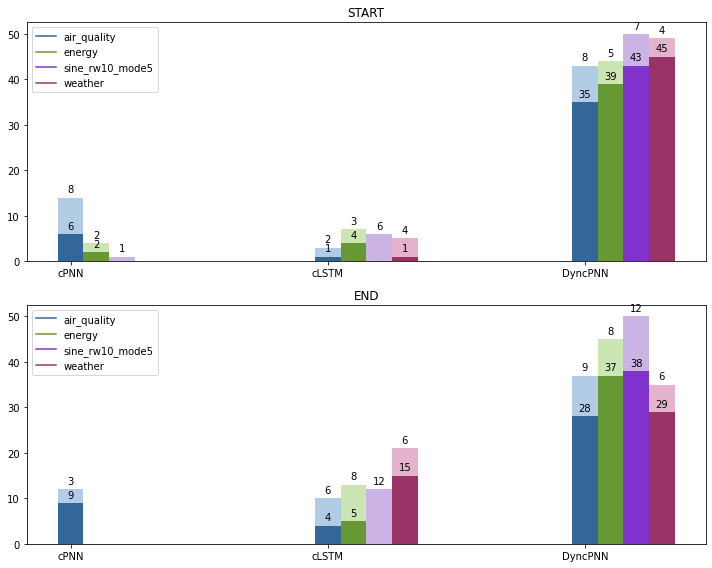

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
build_bar_chart(ax[0], stats_start, "start", df, models)
build_bar_chart(ax[1], stats_end, "end", df, models)
plt.tight_layout()

In [16]:
stats_start[["dataset"]+[c for c in stats_start.columns if "bests" in c]]

,dataset,start_all_bests,start_cLSTM_DyncPNN_bests,start_cPNN_DyncPNN_bests,start_cPNN_cLSTM_bests
0,air_quality,2,2,8,2
1,energy,0,3,2,0
2,sine_rw10_mode5,0,6,1,0
3,weather,0,4,0,0


In [17]:
stats_end[["dataset"]+[c for c in stats_end.columns if "bests" in c]]

,dataset,end_all_bests,end_cLSTM_DyncPNN_bests,end_cPNN_DyncPNN_bests,end_cPNN_cLSTM_bests
0,air_quality,0,6,3,0
1,energy,0,8,0,0
2,sine_rw10_mode5,0,12,0,0
3,weather,0,6,0,0


## Time-series

In [ ]:
def model_name(m):
    if "dyn" in m.lower():
        return "D"
    elif "cpnn" in m.lower():
        return "cP"
    elif "cgru" in m.lower():
        return "cG"
    elif "gin" in m.lower():
        return "GIN"
    else:
        return "A"

In [ ]:
for dataset in datasets:
    df = pd.DataFrame()
    seq_len = set_seq_len(dataset)
    batch_size = set_batch_size(dataset)
    perfs = {}
    for conf in confs_dict[dataset]:
        print(dataset, conf, end="\r")
        with open(os.path.join(path, f"{dataset}_{conf}conf_train", f"performance_{batch_size}_{seq_len}.pkl"), "rb") as f:
            perf = pickle.load(f)
        model1 = list(perf.keys())[0]
        drifts = perf[model1]["drifts"][0]
        drift_lens = [drifts[i+1]-drifts[i] for i in range(len(drifts)-1)] + [len(perf[model1]["task"][metric][0])-drifts[-1]]
        drift_len = np.min(drift_lens)
        for model in perf:
            model_lower = model.lower()
            if "gin" not in model_lower and "cpnn" not in model_lower and "cgru" not in model_lower and model_lower != sml.lower():
                continue
            if model not in perfs:
                perfs[model] = []
            perfs[model].append([])
            for d in drifts:
                perfs[model][-1].append(perf[model]["task"][metric][0][d:d+drift_len])
            perfs[model][-1] = np.mean(np.array(perfs[model][-1]), axis=0)
            df_model = pd.DataFrame()
            df_model["timestamp"] = np.arange(len(perfs[model][-1]))
            df_model[metric] = perfs[model][-1]
            df_model["model"] = model_name(model)
            df_model["conf"] = conf
            df_model["style"] = "solid"
            df = pd.concat([df, df_model])
    with open(os.path.join(path, f"prequential_concept_{metric}_{dataset}.pkl"), "wb") as f:
        pickle.dump(perfs, f)
    df.to_csv(os.path.join(path, f"prequential_concept_{metric}_{dataset}.csv"), index=False)
    print()

sine_rw10_mode5 30
weather 50
